# Exploratory Analysis of Smart Manufacturing Operations

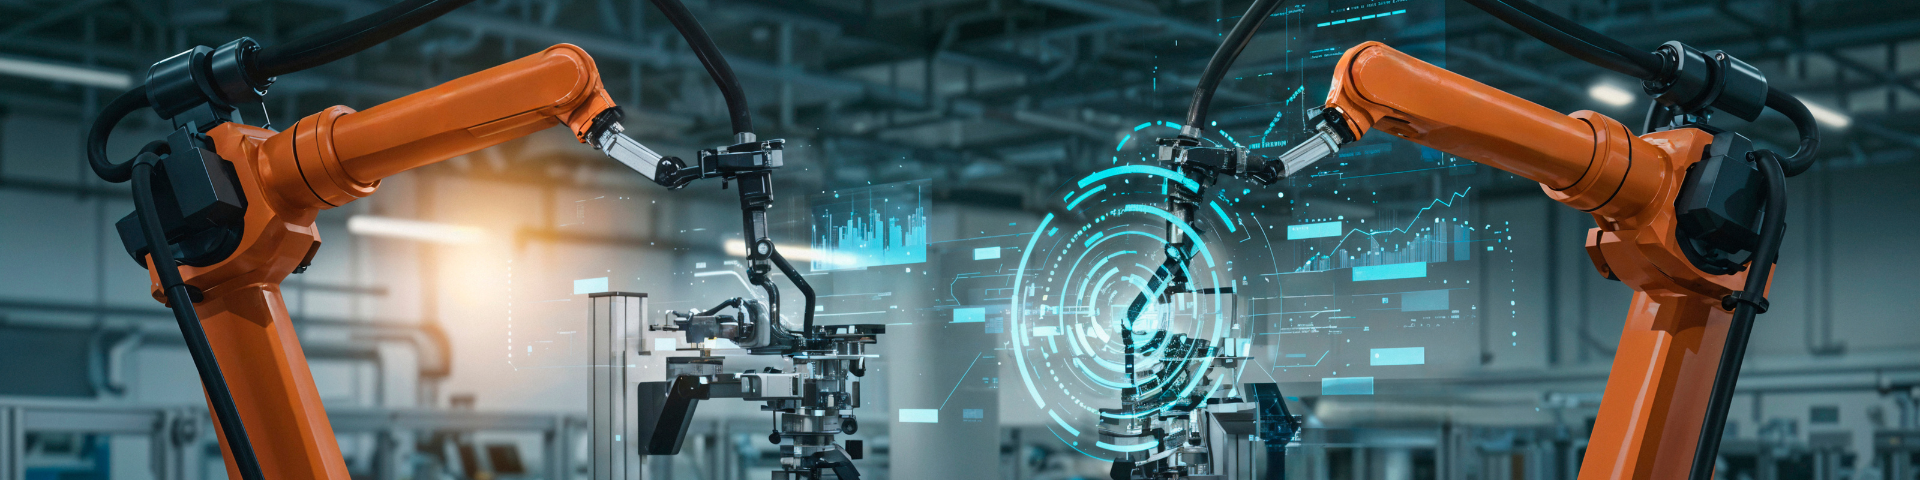

**Dataset:** Smart Manufacturing IIoT Operations Data __[Link](https://www.kaggle.com/datasets/colabsss/smart-manufacturing-iiot-operations-data)__

This notebook presents an exploratory data analysis of an IIoT-enabled
smart manufacturing dataset. The analysis focuses on understanding
operational patterns, distributions, variability, and relationships among
selected manufacturing, environmental, resource, and digital infrastructure
variables.

The analysis follows an exploratory workflow involving:

- Dataset and data-quality assessment
- Descriptive statistics
- Analysis of location and variability
- Distribution analysis
- Covariance and correlation
- Iterative visual exploration

In [1]:
# Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# Visualization settings
sns.set_theme(style="whitegrid")

# Warnings
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

/Users/mac/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Load the dataset

In [2]:
# Load dataset
df = pd.read_csv("digital_infrastructure_smart_manufacturing_dataset.csv")

# Display first five observations
df.head()

,record_id,timestamp,machine_id,production_line,machine_type,shift_type,factory_zone,operator_experience_level,temperature_c,vibration_mm_s,pressure_bar,motor_current_amp,motor_voltage_v,spindle_speed_rpm,torque_nm,load_percent,energy_consumption_kwh,oil_level_percent,coolant_flow_l_min,acoustic_noise_db,ambient_temperature_c,humidity_percent,dust_concentration_mg_m3,air_quality_index,edge_cpu_usage_percent,edge_memory_usage_percent,network_latency_ms,packet_loss_percent,data_throughput_mbps,storage_usage_percent,service_response_time_ms,container_count,active_microservices,resource_allocation_score,scalability_index,fault_tolerance_score,workload_status,operation_state,maintenance_status,infrastructure_operation_level
0,1,2024-01-01 08:00:00,MCH_0103,Line_E,Packaging_Unit,Evening,Zone_2,Intermediate,76.160,2.702,6.500,21.910,417.120,"2,849.220",161.640,69.180,18.733,41.690,29.260,68.250,21.710,58.450,0.227,102.430,70.660,49.840,23.960,14.624,306.190,56.540,86.220,8,31,42.650,62.570,61.290,Balanced,Fault,Not Required,Critical Operation
1,2,2024-01-01 08:10:00,MCH_0271,Line_F,Conveyor_System,Night,Zone_4,Senior,58.910,2.446,7.880,41.980,402.090,"2,670.180",133.940,78.850,29.959,61.240,24.930,79.350,37.290,50.420,0.862,88.830,44.150,69.340,25.210,5.687,222.520,75.210,65.240,27,5,65.530,80.270,81.810,Heavy,Warning,Not Required,Critical Operation
2,3,2024-01-01 08:20:00,MCH_0107,Line_D,CNC_Machine,Morning,Zone_2,Intermediate,67.220,4.870,5.410,21.370,400.860,"1,962.240",159.840,63.670,17.060,53.020,29.580,67.800,32.720,28.820,1.916,121.120,55.230,54.680,28.540,11.102,146.820,62.070,68.110,26,30,60.950,64.580,65.270,Heavy,Warning,Not Required,Critical Operation
3,4,2024-01-01 08:30:00,MCH_0072,Line_B,Conveyor_System,Night,Zone_4,Intermediate,54.990,0.960,7.490,38.530,418.740,886.270,156.940,63.000,20.005,91.880,28.120,63.720,31.800,57.390,1.460,80.630,72.400,54.800,53.860,7.448,187.780,65.050,85.160,23,27,43.060,70.650,64.180,Heavy,Warning,Not Required,Critical Operation
4,5,2024-01-01 08:40:00,MCH_0189,Line_F,CNC_Machine,Night,Zone_2,Expert,72.710,3.632,8.720,35.870,397.070,"2,100.590",60.340,60.630,24.479,84.750,20.310,77.900,39.920,25.060,0.928,61.030,58.210,66.250,20.700,3.067,95.200,60.150,80.260,4,23,62.600,47.410,79.350,Heavy,Warning,Not Required,Critical Operation


## Dataset dimensions

In [3]:
# Number of observations and variables

rows, columns = df.shape

print(f"Number of observations: {rows:,}")
print(f"Number of variables: {columns}")

Number of observations: 12,000
Number of variables: 40


## Dataset structure

In [4]:
# Overview of variables and data types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 40 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   record_id                       12000 non-null  int64  
 1   timestamp                       12000 non-null  object 
 2   machine_id                      12000 non-null  object 
 3   production_line                 12000 non-null  object 
 4   machine_type                    12000 non-null  object 
 5   shift_type                      12000 non-null  object 
 6   factory_zone                    12000 non-null  object 
 7   operator_experience_level       12000 non-null  object 
 8   temperature_c                   12000 non-null  float64
 9   vibration_mm_s                  12000 non-null  float64
 10  pressure_bar                    12000 non-null  float64
 11  motor_current_amp               12000 non-null  float64
 12  motor_voltage_v                 

## Numerical variables

In [5]:
# List numerical variables

numeric_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

print(f"Number of numerical variables: {len(numeric_columns)}")
numeric_columns

Number of numerical variables: 29


['record_id',
 'temperature_c',
 'vibration_mm_s',
 'pressure_bar',
 'motor_current_amp',
 'motor_voltage_v',
 'spindle_speed_rpm',
 'torque_nm',
 'load_percent',
 'energy_consumption_kwh',
 'oil_level_percent',
 'coolant_flow_l_min',
 'acoustic_noise_db',
 'ambient_temperature_c',
 'humidity_percent',
 'dust_concentration_mg_m3',
 'air_quality_index',
 'edge_cpu_usage_percent',
 'edge_memory_usage_percent',
 'network_latency_ms',
 'packet_loss_percent',
 'data_throughput_mbps',
 'storage_usage_percent',
 'service_response_time_ms',
 'container_count',
 'active_microservices',
 'resource_allocation_score',
 'scalability_index',
 'fault_tolerance_score']

## Categorical variables

In [6]:
# List categorical variables

categorical_columns = df.select_dtypes(
    exclude=np.number
).columns.tolist()

print(f"Number of categorical variables: {len(categorical_columns)}")
categorical_columns

Number of categorical variables: 11


['timestamp',
 'machine_id',
 'production_line',
 'machine_type',
 'shift_type',
 'factory_zone',
 'operator_experience_level',
 'workload_status',
 'operation_state',
 'maintenance_status',
 'infrastructure_operation_level']

# Data Preparation and Quality Assessment

## Missing values

In [7]:
# Count missing values

missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": (
        missing_values / len(df) * 100
    )
})

missing_summary.sort_values(
    "Missing Values",
    ascending=False
)

,Missing Values,Missing Percentage
record_id,0,0.000
timestamp,0,0.000
dust_concentration_mg_m3,0,0.000
air_quality_index,0,0.000
edge_cpu_usage_percent,0,0.000
edge_memory_usage_percent,0,0.000
network_latency_ms,0,0.000
packet_loss_percent,0,0.000
data_throughput_mbps,0,0.000
storage_usage_percent,0,0.000


## Duplicate observations

In [8]:
# Count duplicate rows

duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count:,}")

Number of duplicate rows: 0


## Data types

In [9]:
# Summarize data types

dtype_summary = pd.DataFrame({
    "Variable": df.columns,
    "Data Type": df.dtypes.astype(str)
})

dtype_summary

,Variable,Data Type
record_id,record_id,int64
timestamp,timestamp,object
machine_id,machine_id,object
production_line,production_line,object
machine_type,machine_type,object
shift_type,shift_type,object
factory_zone,factory_zone,object
operator_experience_level,operator_experience_level,object
temperature_c,temperature_c,float64
vibration_mm_s,vibration_mm_s,float64


## Basic descriptive overview

In [10]:
# Descriptive overview of numerical variables

df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
record_id,"12,000.000","6,000.500","3,464.246",1.000,"3,000.750","6,000.500","9,000.250","12,000.000"
temperature_c,"12,000.000",67.835,13.001,32.000,59.108,67.570,76.610,118.000
vibration_mm_s,"12,000.000",3.227,2.090,0.150,1.663,2.799,4.307,15.500
pressure_bar,"12,000.000",7.505,1.898,2.000,6.240,7.500,8.780,14.790
motor_current_amp,"12,000.000",33.850,8.528,8.000,28.080,33.880,39.530,66.600
motor_voltage_v,"12,000.000",415.038,19.731,345.000,401.757,414.995,428.505,475.000
spindle_speed_rpm,"12,000.000","2,657.983",722.806,500.000,"2,165.785","2,667.745","3,144.390","5,500.000"
torque_nm,"12,000.000",148.114,45.177,30.000,118.030,147.975,178.160,322.860
load_percent,"12,000.000",63.875,17.497,10.000,51.748,63.750,76.050,100.000
energy_consumption_kwh,"12,000.000",23.528,4.240,7.968,20.701,23.479,26.413,41.674


# Exploratory Analysis of Smart Manufacturing Operations

## Operational Patterns Across Smart Manufacturing Dimensions

### Machine load across machine types

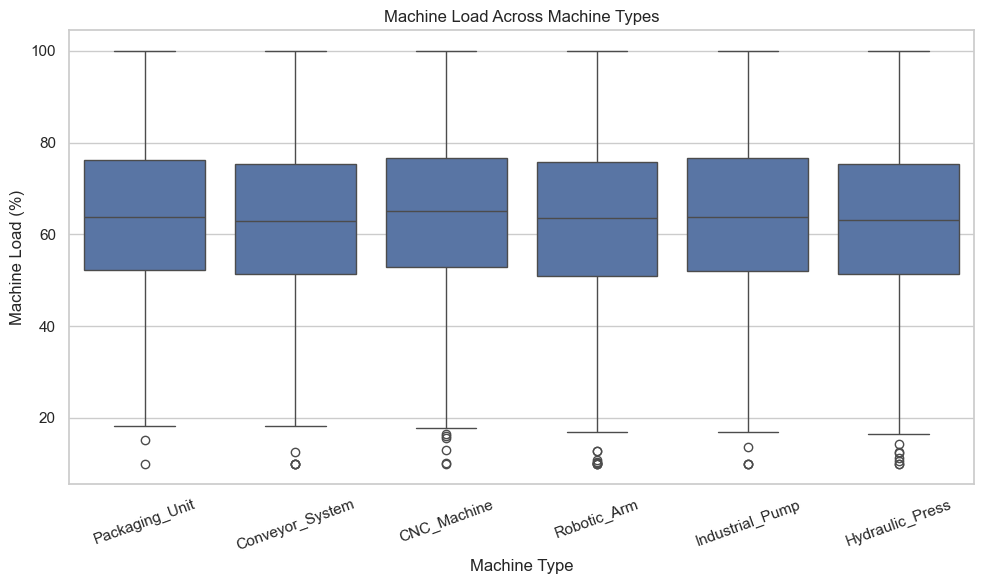

In [11]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="machine_type",
    y="load_percent"
)

plt.title("Machine Load Across Machine Types")
plt.xlabel("Machine Type")
plt.ylabel("Machine Load (%)")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

### Energy consumption across production lines

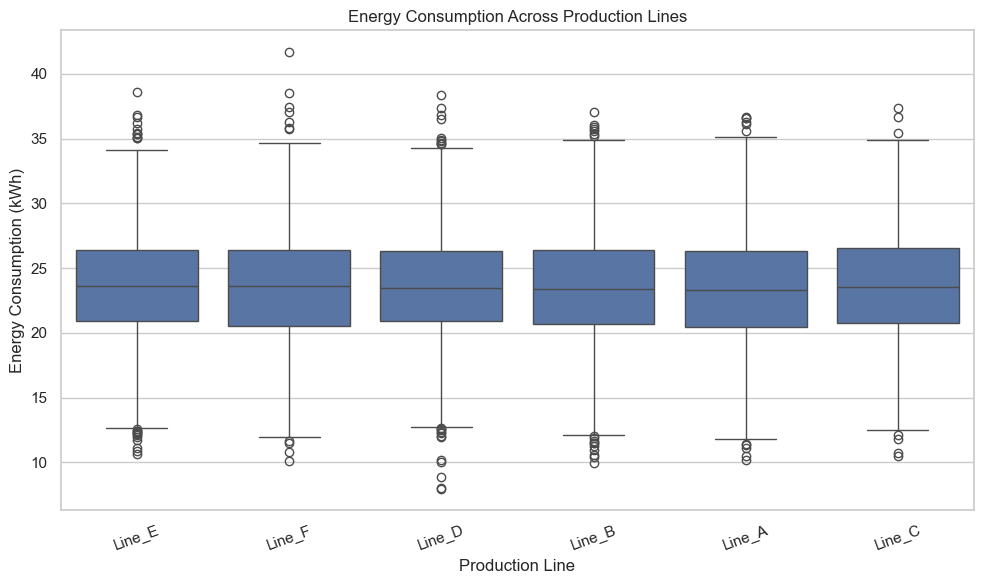

In [12]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="production_line",
    y="energy_consumption_kwh"
)

plt.title("Energy Consumption Across Production Lines")
plt.xlabel("Production Line")
plt.ylabel("Energy Consumption (kWh)")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

### Operating state across shifts

In [13]:
df["operation_state"].value_counts()

operation_state
Warning     4593
Normal      2744
Overload    2516
Fault       2110
Idle          37
Name: count, dtype: int64

In [14]:
# Calculate the proportion of each operating state within each shift

operation_shift = pd.crosstab(
    df["shift_type"],
    df["operation_state"],
    normalize="index"
) * 100

operation_shift

operation_state,Fault,Idle,Normal,Overload,Warning
shift_type,,,,,
Evening,17.528,0.246,22.649,20.556,39.020
Morning,17.576,0.219,23.691,20.820,37.694
Night,17.659,0.504,22.015,21.659,38.163


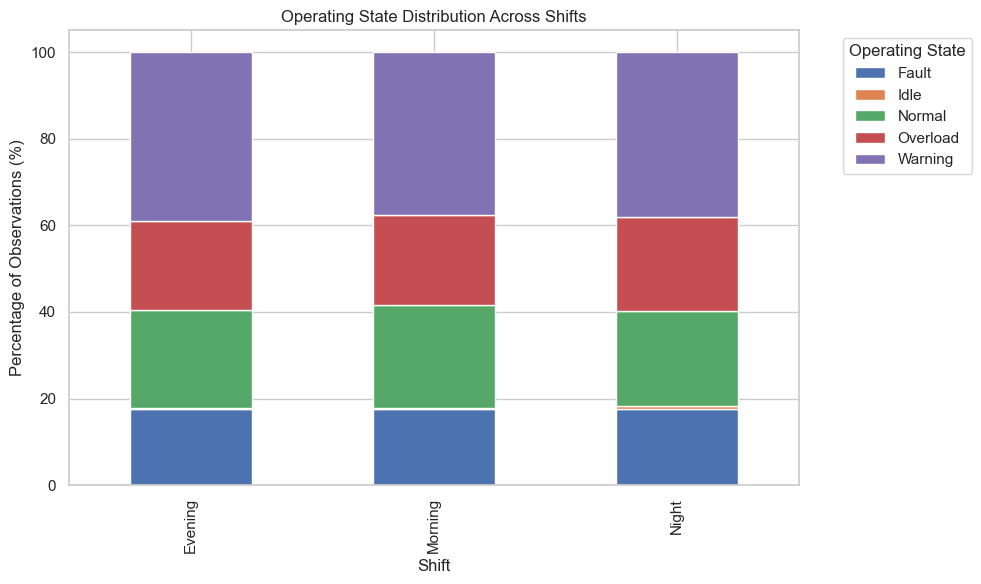

In [15]:
# Visualize operating-state composition by shift

operation_shift.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Operating State Distribution Across Shifts")
plt.xlabel("Shift")
plt.ylabel("Percentage of Observations (%)")
plt.legend(
    title="Operating State",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Workload and edge CPU utilization

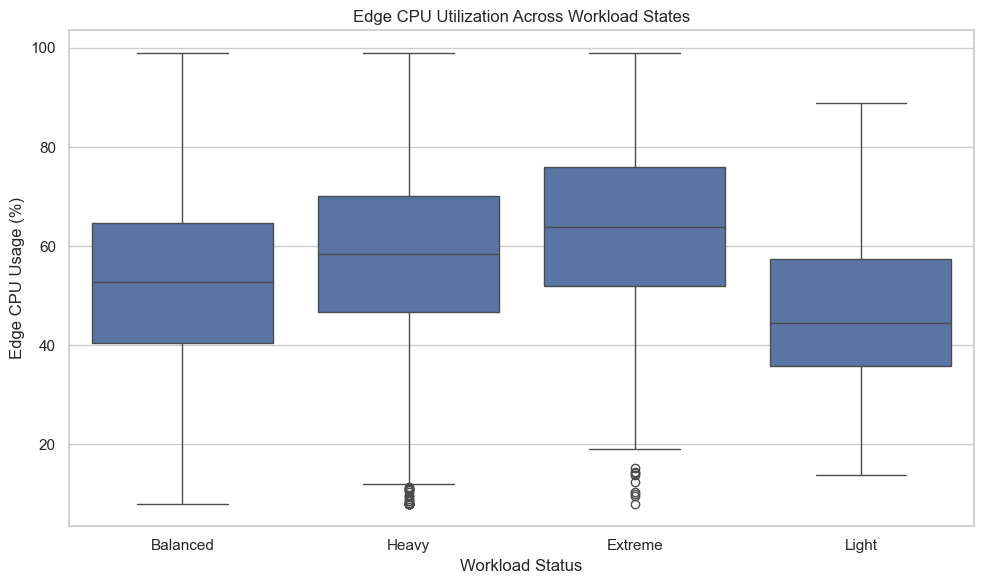

In [16]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="workload_status",
    y="edge_cpu_usage_percent"
)

plt.title("Edge CPU Utilization Across Workload States")
plt.xlabel("Workload Status")
plt.ylabel("Edge CPU Usage (%)")

plt.tight_layout()
plt.show()

## Distribution and Variability of Operational Measures

In [17]:
analysis_variables = [
    "temperature_c",
    "vibration_mm_s",
    "motor_current_amp",
    "load_percent",
    "torque_nm",
    "energy_consumption_kwh",
    "edge_cpu_usage_percent",
    "network_latency_ms"
]

### Measures of location

In [18]:
location_statistics = pd.DataFrame({
    "Mean": df[analysis_variables].mean(),
    "Median": df[analysis_variables].median(),
    "Q1": df[analysis_variables].quantile(0.25),
    "Q3": df[analysis_variables].quantile(0.75)
})

location_statistics

,Mean,Median,Q1,Q3
temperature_c,67.835,67.570,59.108,76.610
vibration_mm_s,3.227,2.799,1.663,4.307
motor_current_amp,33.850,33.880,28.080,39.530
load_percent,63.875,63.750,51.748,76.050
torque_nm,148.114,147.975,118.030,178.160
energy_consumption_kwh,23.528,23.479,20.701,26.413
edge_cpu_usage_percent,57.834,57.905,45.800,70.010
network_latency_ms,26.302,22.190,13.008,35.383


### Measures of variability

In [19]:
variability_statistics = pd.DataFrame({
    "Variance": df[analysis_variables].var(),
    "Standard Deviation": df[analysis_variables].std(),
    "IQR": (
        df[analysis_variables].quantile(0.75)
        - df[analysis_variables].quantile(0.25)
    )
})

variability_statistics

,Variance,Standard Deviation,IQR
temperature_c,169.028,13.001,17.502
vibration_mm_s,4.367,2.090,2.644
motor_current_amp,72.733,8.528,11.450
load_percent,306.153,17.497,24.302
torque_nm,"2,040.934",45.177,60.130
energy_consumption_kwh,17.973,4.240,5.712
edge_cpu_usage_percent,312.531,17.679,24.210
network_latency_ms,316.881,17.801,22.375


### Combined descriptive statistics table

In [20]:
descriptive_statistics = pd.DataFrame({
    "Mean": df[analysis_variables].mean(),
    "Median": df[analysis_variables].median(),
    "Q1": df[analysis_variables].quantile(0.25),
    "Q3": df[analysis_variables].quantile(0.75),
    "Variance": df[analysis_variables].var(),
    "Standard Deviation": df[analysis_variables].std(),
    "IQR": (
        df[analysis_variables].quantile(0.75)
        - df[analysis_variables].quantile(0.25)
    )
})

descriptive_statistics

,Mean,Median,Q1,Q3,Variance,Standard Deviation,IQR
temperature_c,67.835,67.570,59.108,76.610,169.028,13.001,17.502
vibration_mm_s,3.227,2.799,1.663,4.307,4.367,2.090,2.644
motor_current_amp,33.850,33.880,28.080,39.530,72.733,8.528,11.450
load_percent,63.875,63.750,51.748,76.050,306.153,17.497,24.302
torque_nm,148.114,147.975,118.030,178.160,"2,040.934",45.177,60.130
energy_consumption_kwh,23.528,23.479,20.701,26.413,17.973,4.240,5.712
edge_cpu_usage_percent,57.834,57.905,45.800,70.010,312.531,17.679,24.210
network_latency_ms,26.302,22.190,13.008,35.383,316.881,17.801,22.375


### Histograms and density plots

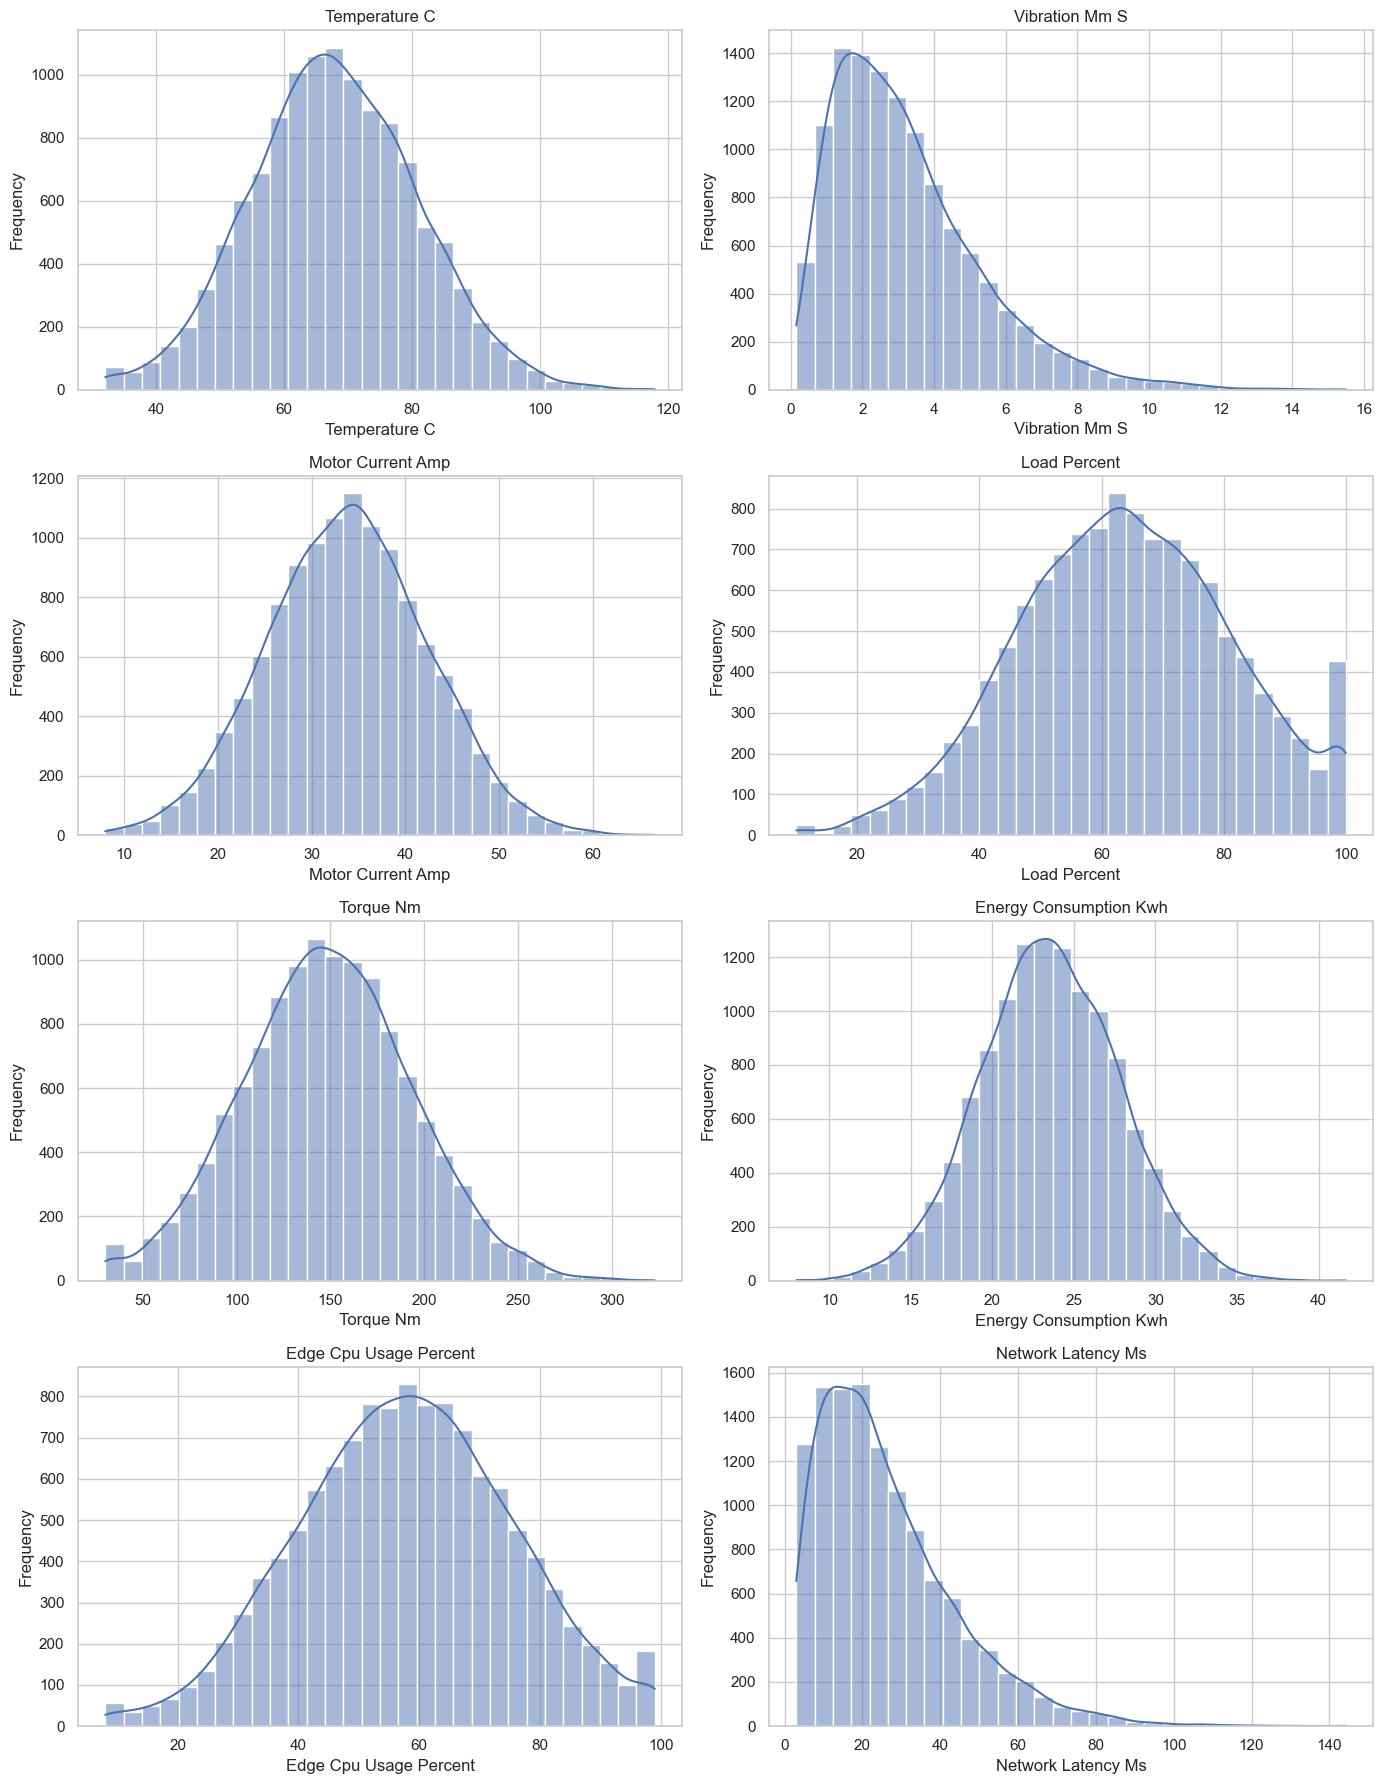

In [21]:
fig, axes = plt.subplots(
    4, 2,
    figsize=(14, 18)
)

axes = axes.flatten()

for ax, variable in zip(axes, analysis_variables):
    
    sns.histplot(
        data=df,
        x=variable,
        kde=True,
        bins=30,
        ax=ax
    )
    
    ax.set_title(
        variable.replace("_", " ").title()
    )
    
    ax.set_xlabel(
        variable.replace("_", " ").title()
    )
    
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### Boxplots

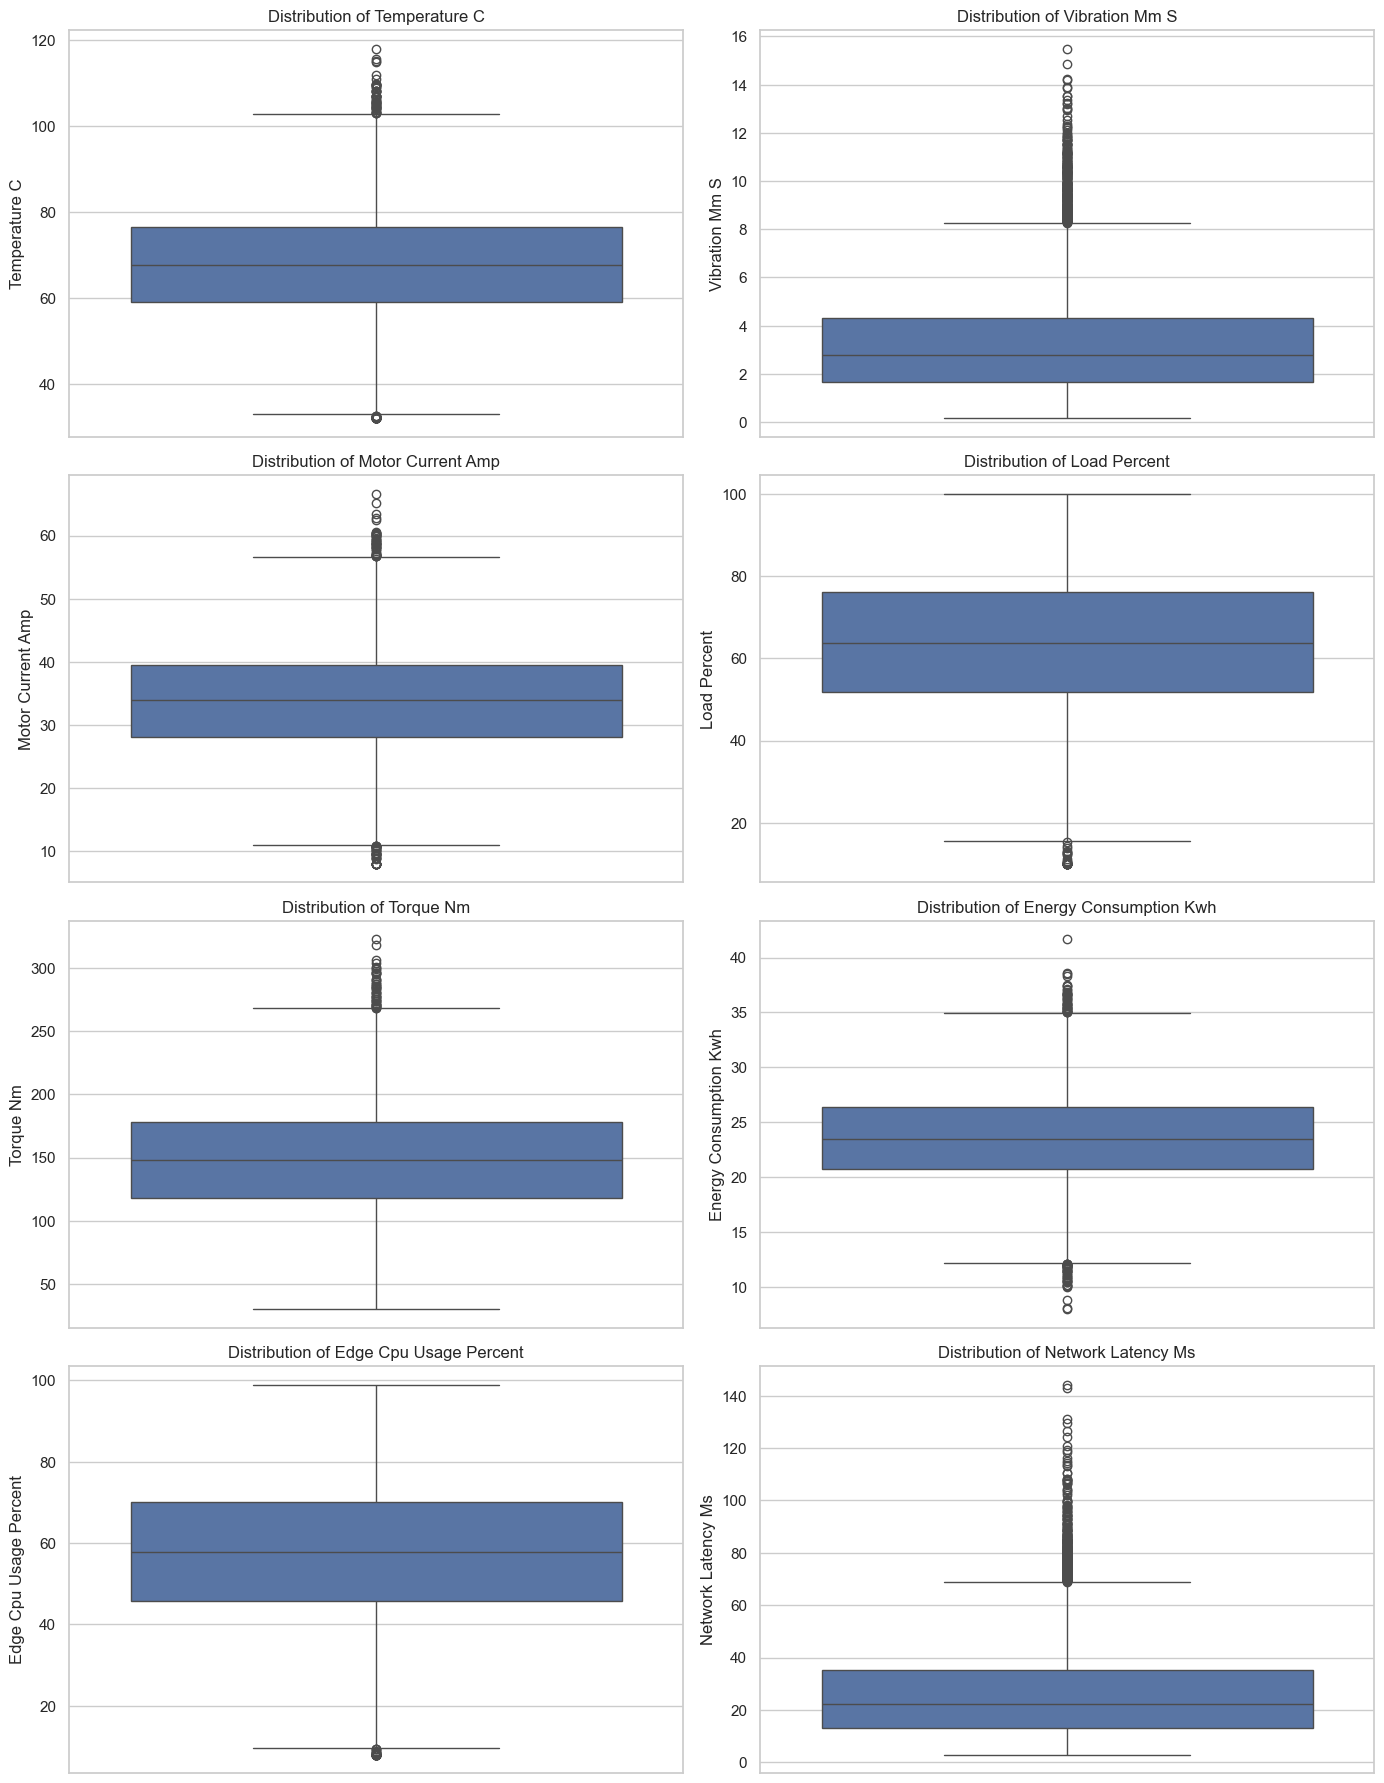

In [22]:
fig, axes = plt.subplots(
    4, 2,
    figsize=(14, 18)
)

axes = axes.flatten()

for ax, variable in zip(axes, analysis_variables):
    
    sns.boxplot(
        data=df,
        y=variable,
        ax=ax
    )
    
    ax.set_title(
        f"Distribution of {variable.replace('_', ' ').title()}"
    )
    
    ax.set_ylabel(
        variable.replace("_", " ").title()
    )

plt.tight_layout()
plt.show()

## Relationships Among Smart Manufacturing Variables

In [23]:
relationship_variables = [
    "temperature_c",
    "vibration_mm_s",
    "motor_current_amp",
    "spindle_speed_rpm",
    "torque_nm",
    "load_percent",
    "energy_consumption_kwh",
    "edge_cpu_usage_percent",
    "network_latency_ms"
]

### Covariance matrix

In [24]:
covariance_matrix = df[
    relationship_variables
].cov()

covariance_matrix

,temperature_c,vibration_mm_s,motor_current_amp,spindle_speed_rpm,torque_nm,load_percent,energy_consumption_kwh,edge_cpu_usage_percent,network_latency_ms
temperature_c,169.028,0.079,-1.263,39.383,-5.504,-0.597,-0.991,2.220,-0.617
vibration_mm_s,0.079,4.367,0.269,9.931,1.257,-0.028,0.110,0.717,-0.096
motor_current_amp,-1.263,0.269,72.733,138.785,-0.305,-0.153,23.041,-1.149,0.789
spindle_speed_rpm,39.383,9.931,138.785,"522,448.123",-161.701,-24.194,45.110,32.267,21.472
torque_nm,-5.504,1.257,-0.305,-161.701,"2,040.934",5.320,0.528,-1.366,0.131
load_percent,-0.597,-0.028,-0.153,-24.194,5.320,306.153,36.574,-1.531,-2.556
energy_consumption_kwh,-0.991,0.110,23.041,45.110,0.528,36.574,17.973,-1.134,-0.341
edge_cpu_usage_percent,2.220,0.717,-1.149,32.267,-1.366,-1.531,-1.134,312.531,-4.494
network_latency_ms,-0.617,-0.096,0.789,21.472,0.131,-2.556,-0.341,-4.494,316.881


In [25]:
selected_covariance = pd.DataFrame({
    "Pair": [
        "Load - Energy",
        "Energy - Motor Current",
        "Load - Torque",
        "Temperature - Vibration"
    ],
    "Covariance": [
        df["load_percent"].cov(
            df["energy_consumption_kwh"]
        ),
        df["energy_consumption_kwh"].cov(
            df["motor_current_amp"]
        ),
        df["load_percent"].cov(
            df["torque_nm"]
        ),
        df["temperature_c"].cov(
            df["vibration_mm_s"]
        )
    ]
})

selected_covariance

,Pair,Covariance
0,Load - Energy,36.574
1,Energy - Motor Current,23.041
2,Load - Torque,5.320
3,Temperature - Vibration,0.079


### Correlation matrix

In [26]:
correlation_matrix = df[
    relationship_variables
].corr()

correlation_matrix

,temperature_c,vibration_mm_s,motor_current_amp,spindle_speed_rpm,torque_nm,load_percent,energy_consumption_kwh,edge_cpu_usage_percent,network_latency_ms
temperature_c,1.000,0.003,-0.011,0.004,-0.009,-0.003,-0.018,0.010,-0.003
vibration_mm_s,0.003,1.000,0.015,0.007,0.013,-0.001,0.012,0.019,-0.003
motor_current_amp,-0.011,0.015,1.000,0.023,-0.001,-0.001,0.637,-0.008,0.005
spindle_speed_rpm,0.004,0.007,0.023,1.000,-0.005,-0.002,0.015,0.003,0.002
torque_nm,-0.009,0.013,-0.001,-0.005,1.000,0.007,0.003,-0.002,0.000
load_percent,-0.003,-0.001,-0.001,-0.002,0.007,1.000,0.493,-0.005,-0.008
energy_consumption_kwh,-0.018,0.012,0.637,0.015,0.003,0.493,1.000,-0.015,-0.005
edge_cpu_usage_percent,0.010,0.019,-0.008,0.003,-0.002,-0.005,-0.015,1.000,-0.014
network_latency_ms,-0.003,-0.003,0.005,0.002,0.000,-0.008,-0.005,-0.014,1.000


### Correlation heatmap

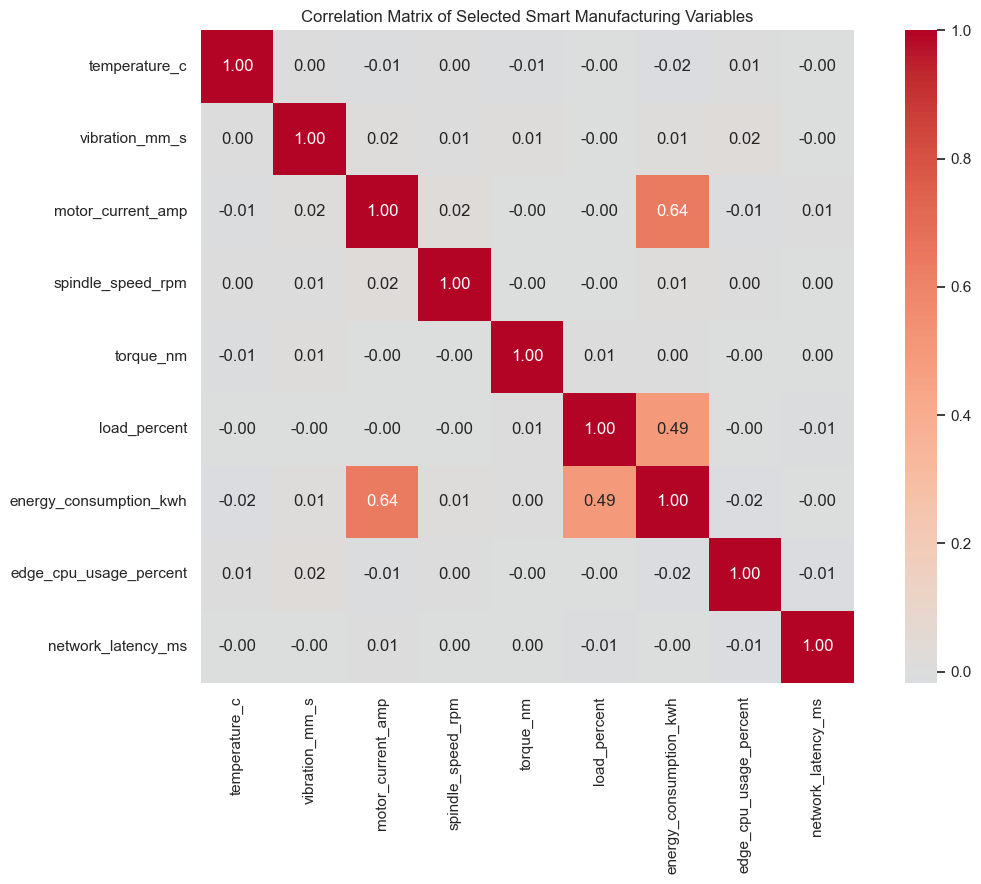

In [27]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title(
    "Correlation Matrix of Selected Smart Manufacturing Variables"
)

plt.tight_layout()
plt.show()

### Relationship: Load and energy

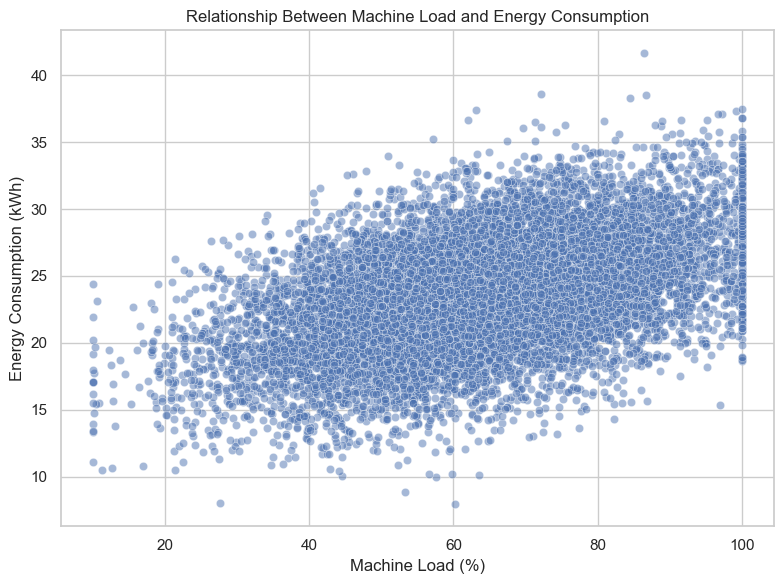

In [28]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="load_percent",
    y="energy_consumption_kwh",
    alpha=0.5
)

plt.title("Relationship Between Machine Load and Energy Consumption")
plt.xlabel("Machine Load (%)")
plt.ylabel("Energy Consumption (kWh)")

plt.tight_layout()
plt.show()

### Relationship: Energy and motor current

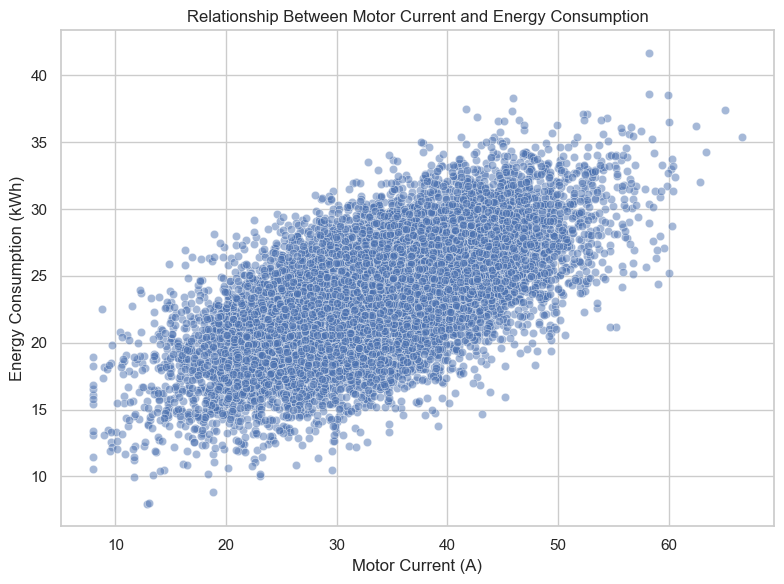

In [29]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="motor_current_amp",
    y="energy_consumption_kwh",
    alpha=0.5
)

plt.title(
    "Relationship Between Motor Current and Energy Consumption"
)

plt.xlabel("Motor Current (A)")
plt.ylabel("Energy Consumption (kWh)")

plt.tight_layout()
plt.show()

### Relationship: Load and torque

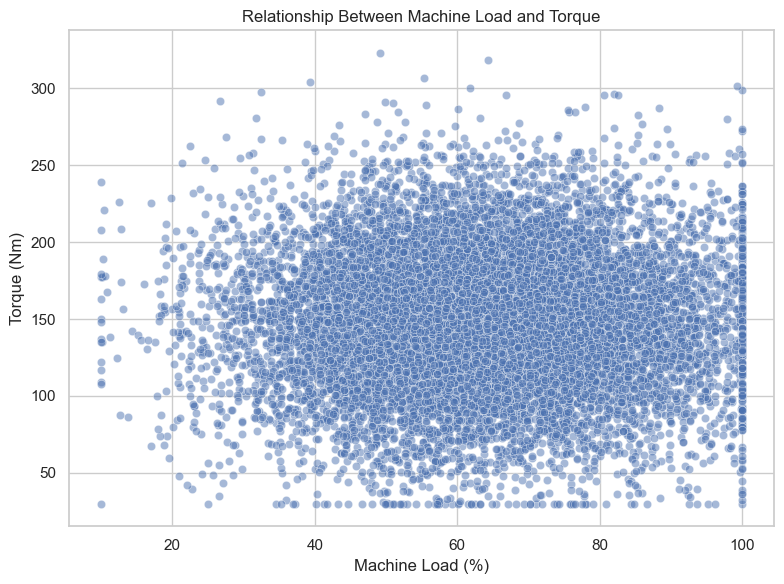

In [30]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="load_percent",
    y="torque_nm",
    alpha=0.5
)

plt.title("Relationship Between Machine Load and Torque")
plt.xlabel("Machine Load (%)")
plt.ylabel("Torque (Nm)")

plt.tight_layout()
plt.show()

### Relationship: Temperature and vibration

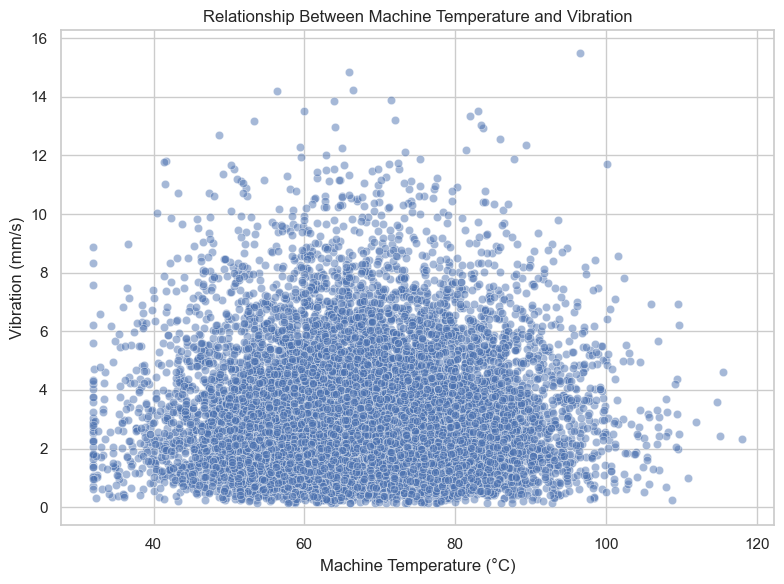

In [31]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="temperature_c",
    y="vibration_mm_s",
    alpha=0.5
)

plt.title(
    "Relationship Between Machine Temperature and Vibration"
)

plt.xlabel("Machine Temperature (°C)")
plt.ylabel("Vibration (mm/s)")

plt.tight_layout()
plt.show()

## Emerging Patterns and Anomalies

### Vibration across machine types

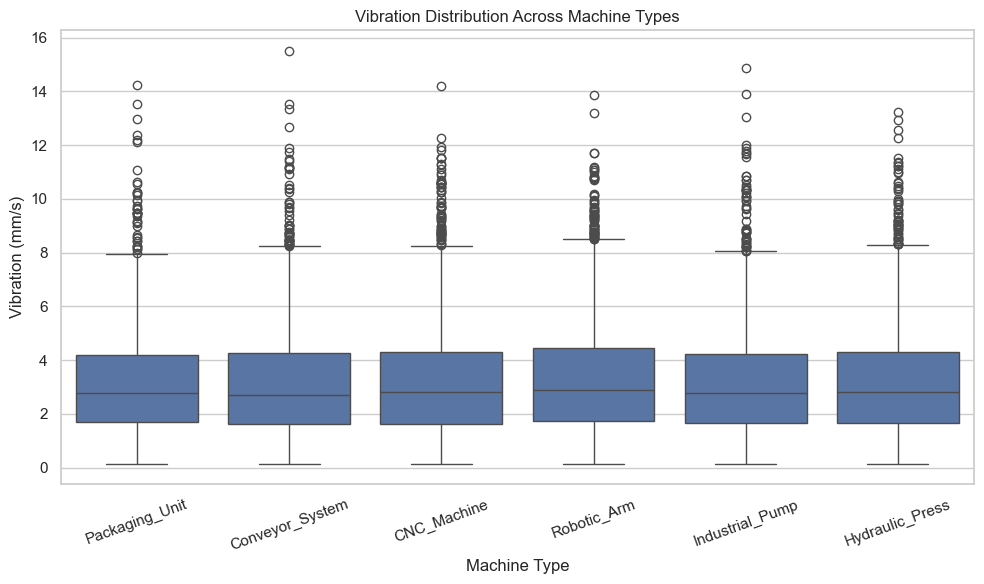

In [32]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="machine_type",
    y="vibration_mm_s"
)

plt.title("Vibration Distribution Across Machine Types")
plt.xlabel("Machine Type")
plt.ylabel("Vibration (mm/s)")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

### Vibration across production lines

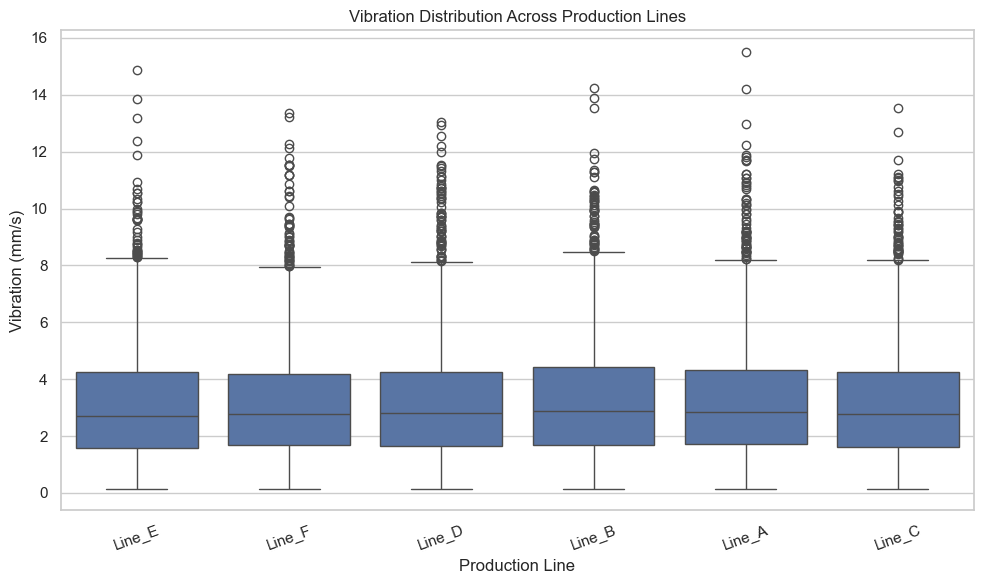

In [33]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="production_line",
    y="vibration_mm_s"
)

plt.title("Vibration Distribution Across Production Lines")
plt.xlabel("Production Line")
plt.ylabel("Vibration (mm/s)")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

### Energy consumption across workload states

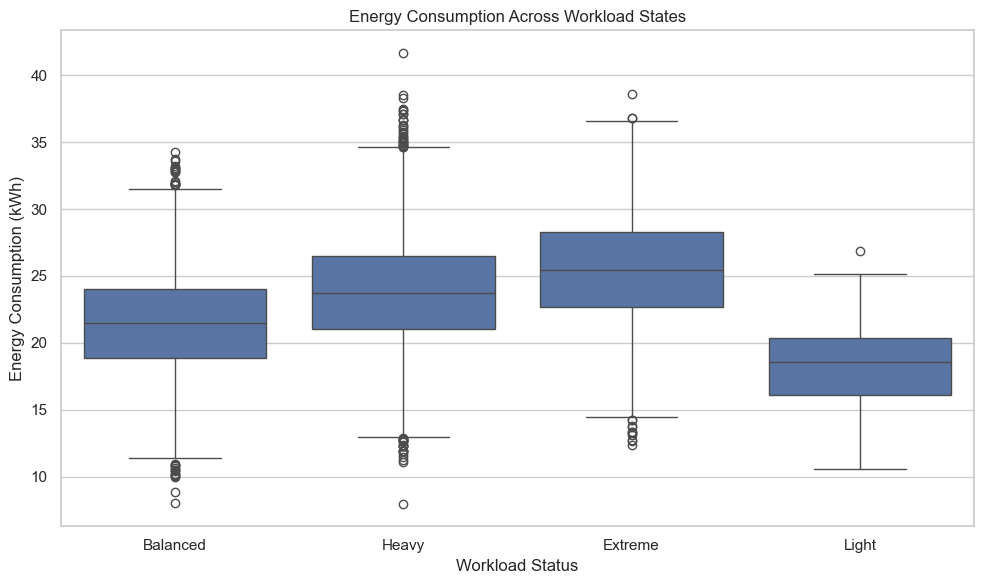

In [34]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="workload_status",
    y="energy_consumption_kwh"
)

plt.title("Energy Consumption Across Workload States")
plt.xlabel("Workload Status")
plt.ylabel("Energy Consumption (kWh)")

plt.tight_layout()
plt.show()

-------

__End.__